# Imports

In [1]:
import numpy as np
import anndata as ad
from huggingface_hub import hf_hub_download
import phate
import matplotlib.pyplot as plt
from dse_dsmi import diffusion_spectral_entropy, diffusion_spectral_mutual_information
import os
import requests
import anndata as ad
from sklearn.datasets import make_blobs
import sklearn
np.set_printoptions(suppress=True)

/opt/miniconda3/envs/dse.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Shared helpers and constants used by every dataset below
num_datapoints = 1000

def make_DSE_data(data, **kwargs):
    """Compute Diffusion Spectral Entropy over a range of diffusion times t."""
    t_vals = [1, 10, 25, 50, 100, 250, 500, 650, 800, 1000, 2000]
    DSE_graph = np.zeros((len(t_vals), 2))
    for i, t in enumerate(t_vals):
        DSE = diffusion_spectral_entropy(embedding_vectors=data, t=t, **kwargs)
        DSE_graph[i, 0] = t
        DSE_graph[i, 1] = DSE
    return DSE_graph

def rotate_data(data):
    """Embed 2-D data into 100-D via a random orthonormal rotation."""
    Dimension = 100
    rand_matrix = np.random.randn(Dimension, 2)
    orthonormal_matrix, _ = np.linalg.qr(rand_matrix)
    orthonormal_matrix_2d = orthonormal_matrix[:, :2]
    return data @ orthonormal_matrix_2d.T

# Control 
Showing that scDSE provides the intended use.
scDSE should converge to `log_2(n_clusters)`, which will be shown here

In [3]:
control_scale = 10
control_data, _ = sklearn.datasets.make_blobs(n_samples = num_datapoints, cluster_std = control_scale/15, centers=[(5, -5), (-5, -5), (0, 5)], random_state = 1)

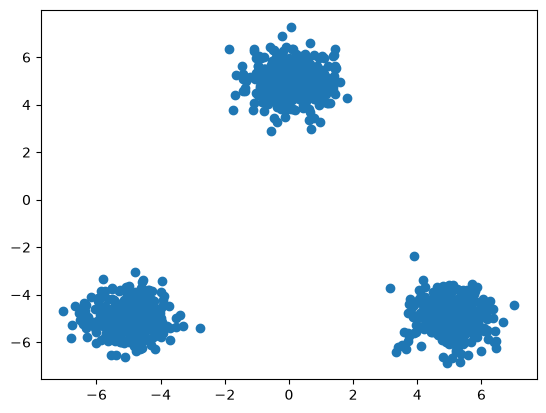

In [4]:
plt.scatter(control_data[:,0], control_data[:,1])

In [5]:
control_highd = rotate_data(control_data)
control_highd.shape

(1000, 100)

In [6]:
control_DSE = make_DSE_data(control_highd)

In [7]:
2 ** control_DSE[-1,-1]

np.float64(3.0052160760933817)

In [8]:
control_scale2 = 100
control_data2, _ = sklearn.datasets.make_blobs(n_samples = num_datapoints, cluster_std = control_scale2/15, centers=[(50, -50), (-50, -50), (0, 50)], random_state = 1)

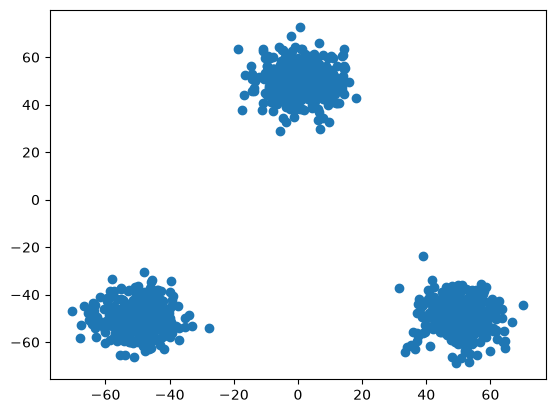

In [9]:
plt.scatter(control_data2[:,0], control_data2[:,1])

In [10]:
control_highd2 = rotate_data(control_data2)
control_DSE2 = make_DSE_data(control_highd2)
2 ** control_DSE2[-1,-1]

np.float64(3.00521607609343)

As expected, DSE converges to the number of clusters. We can also see that scDSE is scale invariant, where as DSE needs hyperparameter tuning for neighborhood size

# Generating DSE Sweeps on Different Types

## Clustered Data

In [11]:
clustered_id = "SCD-0015"
clustered_adata = ad.read_h5ad(hf_hub_download(repo_id="scShape-Benchmark/scShapeBench", repo_type="dataset", filename=f"data/scRNAseq/{clustered_id}.h5ad"))

In [12]:
clustered_adata

AnnData object with n_obs × n_vars = 1973 × 18961
    obs: 'n_genes', 'leiden'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells', 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'hvg', 'leiden', 'log1p', 'neighbors', 'pca'
    obsm: 'X_pca'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [13]:
clustered_op = phate.PHATE(knn = 15, decay = 60, verbose = 0)
clustered_phate = clustered_op.fit_transform(clustered_adata.X)

    SGD-MDS may not have converged: stress changed by -2.5% in final iterations. Consider increasing n_iter or adjusting learning_rate.


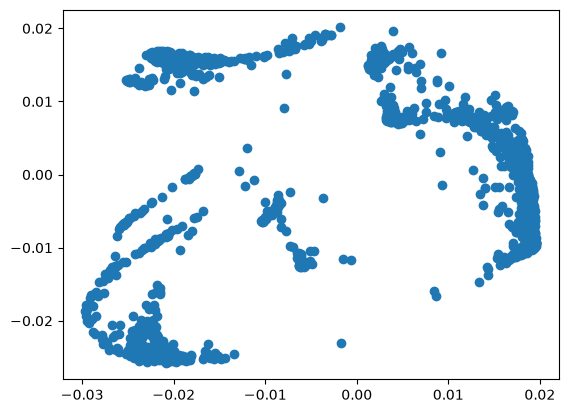

In [14]:
plt.scatter(clustered_phate[:, 0], clustered_phate[:,1])

In [15]:
clustered_DSE = make_DSE_data(clustered_adata.X.toarray())

In [16]:
2 ** (clustered_DSE[-2,-1])

np.float64(3.8625966947212964)

This lines up with the roughly 4 clusters seen above

## Non Cluster Clean Data
This represents continuous forms of data

In [17]:
nonclustered_id = "SCD-0010"
nonclustered_adata = ad.read_h5ad(hf_hub_download(repo_id="scShape-Benchmark/scShapeBench", repo_type="dataset", filename=f"data/scRNAseq/{nonclustered_id}.h5ad"))

In [18]:
nonclustered_op = phate.PHATE(knn = 100, t = 12, decay = 60, verbose = 0)
nonclustered_phate = nonclustered_op.fit_transform(nonclustered_adata.X.toarray())

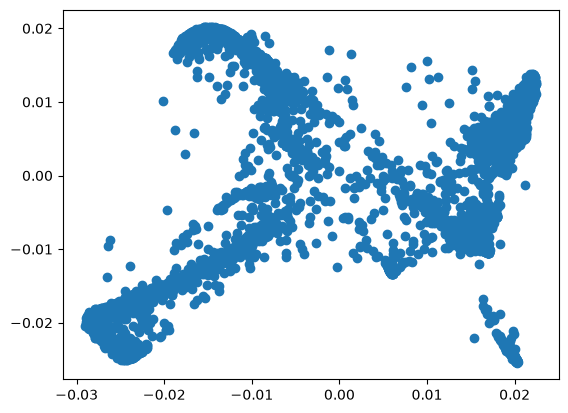

In [19]:
plt.scatter(nonclustered_phate[:,0], nonclustered_phate[:,1])

In [20]:
nonclustered_DSE = make_DSE_data(nonclustered_adata.X.toarray())

In [21]:
nonclustered_DSE[-1,-1]

np.float64(0.0007278648865505067)

## Noisy or Bad Data
Noisy-dominated data should have a similar DSE signature as a simple Gaussian blob (next section). Here we use **human embryonic male gonadal tissue** scRNA-seq as the noisy example.

In [22]:
noisy_url = "https://datasets.cellxgene.cziscience.com/d6298cb3-63fb-400d-b81b-00df0bc48734.h5ad"

# Cache the download in a gitignored data/ dir at the repo root (not in notebooks/).
data_dir = os.path.join("..", "data")
os.makedirs(data_dir, exist_ok=True)
noisy_path = os.path.join(data_dir, "embryonic_gonad.h5ad")

if not os.path.exists(noisy_path):
    with requests.get(noisy_url, stream=True) as resp:
        resp.raise_for_status()
        with open(noisy_path, "wb") as f:
            for chunk in resp.iter_content(chunk_size=8 << 20):
                f.write(chunk)

noisy_adata = ad.read_h5ad(noisy_path)

In [23]:
noisy_op = phate.PHATE(verbose = 0)
noisy_phate = noisy_op.fit_transform(noisy_adata.X)

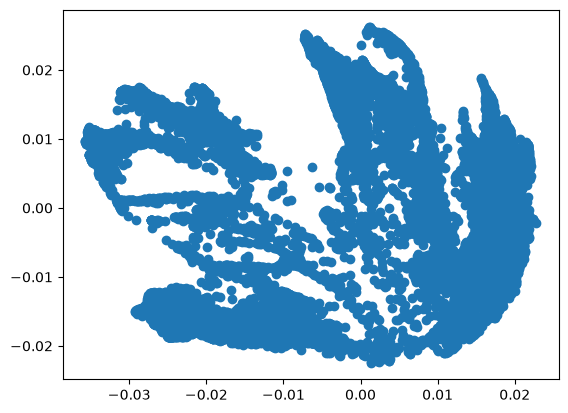

In [24]:
plt.scatter(noisy_phate[:,0], noisy_phate[:,1])

In [25]:
noisy_DSE = make_DSE_data(noisy_adata.X.toarray())

In [26]:
noisy_DSE

array([[   1.        ,   10.47342725],
       [  10.        ,    7.04263202],
       [  25.        ,    5.56945232],
       [  50.        ,    4.6742594 ],
       [ 100.        ,    3.85578695],
       [ 250.        ,    2.82448852],
       [ 500.        ,    2.14620682],
       [ 650.        ,    1.77560041],
       [ 800.        ,    1.62430588],
       [1000.        ,    1.30317563],
       [2000.        ,    0.54820916]])

## One Gaussian Blob
To be used as a comparison against noisy data and non cluster data

In [27]:
gaussian_scale = 40
gaussian_data, gaussian_labels = sklearn.datasets.make_blobs(n_samples = num_datapoints, cluster_std = gaussian_scale/10, centers = 1, random_state = 1)

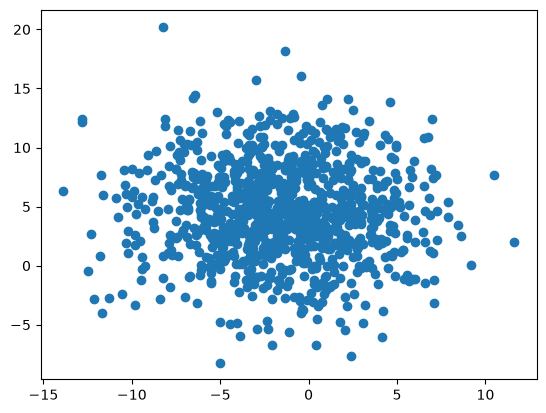

In [28]:
plt.scatter(gaussian_data[:,0], gaussian_data[:,1])

Rotating the aussian blob data to higher dimensions to simulate noisy single cell data

In [29]:
gaussian_highd = rotate_data(gaussian_data)
gaussian_highd.shape

(1000, 100)

In [30]:
gaussian_DSE = make_DSE_data(gaussian_highd)

In [31]:
gaussian_DSE

array([[   1.        ,    9.15435117],
       [  10.        ,    6.8318691 ],
       [  25.        ,    6.07640131],
       [  50.        ,    5.41411924],
       [ 100.        ,    4.59499532],
       [ 250.        ,    3.2951961 ],
       [ 500.        ,    2.27499062],
       [ 650.        ,    1.90306584],
       [ 800.        ,    1.61092899],
       [1000.        ,    1.29692042],
       [2000.        ,    0.40000346]])

# Comparison

In [32]:
# Side-by-side comparison of DSE across datasets at two diffusion times.
# scDSE converges toward log2(n_clusters); 2^DSE recovers the effective cluster count.
results = {
    "Control — 3 Gaussian blobs":       (control_DSE,       "target log2(3) ≈ 1.58"),
    "Clustered — SCD-0015":             (clustered_DSE,     "~4 biological clusters"),
    "Non-cluster clean — SCD-0010":     (nonclustered_DSE,  "continuum, no discrete clusters"),
    "Noisy or bad — embryonic gonad":    (noisy_DSE,         "collapses toward 0"),
    "Gaussian blob — rotated to 100-D": (gaussian_DSE,      "single blob, no structure"),
}

name_w = max(len(k) for k in results)

def print_comparison(t_target):
    header = f"{'Dataset':<{name_w}}  {'t':>6}  {'DSE':>9}  {'2^DSE':>8}   {'Interpretation'}"
    rule = "=" * len(header)
    print(rule)
    print(f"  scDSE comparison — Diffusion Spectral Entropy at t = {t_target}")
    print(rule)
    print(header)
    print("-" * len(header))
    for name, (arr, note) in results.items():
        idx     = int(np.where(arr[:, 0] == t_target)[0][0])
        dse_val = arr[idx, 1]
        eff     = 2 ** dse_val
        print(f"{name:<{name_w}}  {arr[idx, 0]:>6.0f}  {dse_val:>9.4f}  {eff:>8.2f}   {note}")
    print(rule)

print_comparison(1000)
print()
print_comparison(2000)

  scDSE comparison — Diffusion Spectral Entropy at t = 1000
Dataset                                t        DSE     2^DSE   Interpretation
------------------------------------------------------------------------------
Control — 3 Gaussian blobs          1000     1.7006      3.25   target log2(3) ≈ 1.58
Clustered — SCD-0015                1000     1.9496      3.86   ~4 biological clusters
Non-cluster clean — SCD-0010        1000     0.0073      1.01   continuum, no discrete clusters
Noisy or bad — embryonic gonad      1000     1.3032      2.47   collapses toward 0
Gaussian blob — rotated to 100-D    1000     1.2969      2.46   single blob, no structure

  scDSE comparison — Diffusion Spectral Entropy at t = 2000
Dataset                                t        DSE     2^DSE   Interpretation
------------------------------------------------------------------------------
Control — 3 Gaussian blobs          2000     1.5875      3.01   target log2(3) ≈ 1.58
Clustered — SCD-0015               

As shown above, the control shows that scDSE has its intended affect. DSE converged to `log2(n_clusters)`; in this case `n_clusters = 3`. **Clean, well-clustered data** plateaus near `log2(n_clusters)` as well, as there were roughly 4 clusters in this data. However, due to noise, DSE with more than `t = 1000` will underestimate the number of clusters. The **noisy or bad data** and **gaussian blob** decays slower than **non-cluster clean data**, which decays to 0 quickly. In all cases, the DSE graph should be distinguishable